# 🔴 PROJECT · Hard · Wine Chemistry - Linkage × k Silhouette Grid

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Run a systematic model-selection grid: **3 linkages (ward/complete/average)
   × 4 granularities (k=3..6)** on real 11-D wine chemistry
2. Visualize the result as a silhouette HEATMAP and defend the winner
3. Cut the winning tree, profile clusters by sensory quality, and report
   findings with honest limitations

⚠️ `quality` remains quarantined until evaluation time - the entire grid runs
on chemistry alone.

In [1]:
# ---- Setup ------------------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Course data resolver: walk up to '02_machine_learning', download once."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("02_machine_learning folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)
    return fpath

WINE_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/winequality-red.csv")

## 1. Load & prepare

In [2]:
wine = pd.read_csv(get_data("winequality-red.csv", WINE_URL), sep=";")
quality = wine.pop("quality")                    # sensory truth: eval-only
chem_cols = list(wine.columns)                   # 11 chemical features

scaler = StandardScaler()                        # SO2 (0-289) vs density (~1) - no contest
X = scaler.fit_transform(wine[chem_cols])
print(f"{X.shape[0]} wines × {X.shape[1]} scaled chemicals")

1599 wines × 11 scaled chemicals


## 2. The grid - every linkage at every k

Twelve fits total. Each returns labels; each labeling gets ONE silhouette
number. The heatmap makes trade-offs visible at a glance.

k,3,4,5,6
linkage,,,,
average,0.563,0.534,0.514,0.509
complete,0.356,0.172,0.173,0.167
ward,0.158,0.171,0.154,0.150


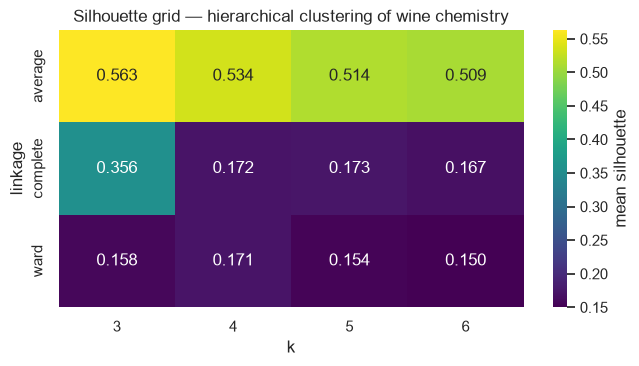

WINNER: linkage=average, k=3 (silhouette=0.563)


In [3]:
linkages = ["ward", "complete", "average"]
ks = [3, 4, 5, 6]                                 # coarser k's were explored in K-Means module
rows = []
for link in linkages:
    for k in ks:
        lab = AgglomerativeClustering(n_clusters=k, linkage=link).fit_predict(X)
        rows.append({"linkage": link, "k": k,
                     "silhouette": round(silhouette_score(X, lab), 3)})
grid = pd.DataFrame(rows).pivot(index="linkage", columns="k",
                                values="silhouette")
display(grid)                                     # noqa: F821 raw numbers first...

plt.figure(figsize=(7.5, 3.6))                    # ...then as heat
sns.heatmap(grid, annot=True, fmt=".3f", cmap="viridis",
            cbar_kws=dict(label="mean silhouette"))
plt.title("Silhouette grid - hierarchical clustering of wine chemistry")
plt.show()

best_link, best_k = grid.stack().idxmax()         # champion cell
print(f"WINNER: linkage={best_link}, k={best_k} "
      f"(silhouette={grid.stack().max():.3f})")

💡 Expect modest absolute values (< ~0.25): in 11-D, distance concentration
keeps ALL silhouettes low. The grid ranks configurations RELATIVELY - which
is exactly what model selection needs.

## 3. The winning tree

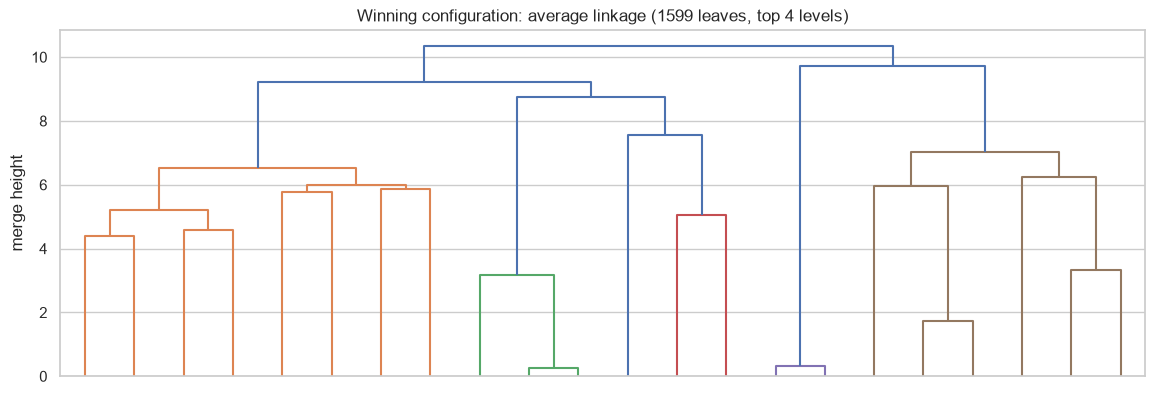

In [4]:
Z_best = linkage(X, method=best_link)             # scipy tree matching sklearn rule
fig, ax = plt.subplots(figsize=(14, 4.5))
dendrogram(Z_best, truncate_mode="level", p=4,    # top-of-tree readability
           color_threshold=None, ax=ax, no_labels=True)
ax.set_title(f"Winning configuration: {best_link} linkage ({len(X)} leaves, top 4 levels)")
ax.set_ylabel("merge height"); plt.show()

labels_best = AgglomerativeClustering(n_clusters=best_k,
                                      linkage=best_link).fit_predict(X)
wine["cluster"] = labels_best                     # attach for profiling

## 4. Do clusters differ in quality?

,size,mean,std
cluster,,,
0,1589,5.64,0.81
1,8,5.38,0.74
2,2,7.00,0.00


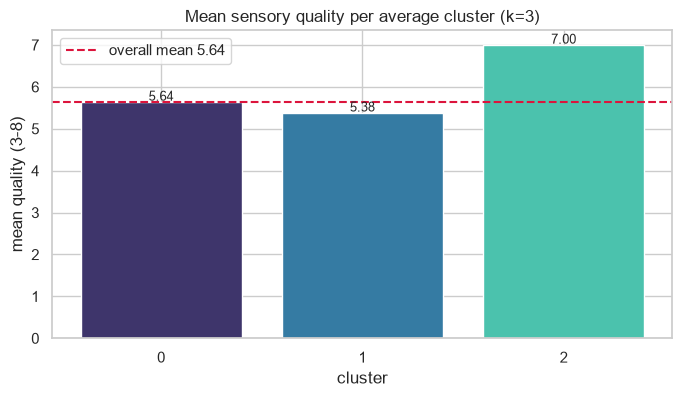

In [5]:
qtab = quality.groupby(wine["cluster"]).agg(["size", "mean", "std"]).round(2)
display(qtab)                                     # noqa: F821

fig, ax = plt.subplots(figsize=(8, 4))
means = qtab["mean"]                                     # SeriesGroupBy-agg -> flat columns
bars = ax.bar(qtab.index.astype(str), means.values,
              color=sns.color_palette("mako", len(qtab)))
ax.axhline(quality.mean(), ls="--", color="crimson",
           label=f"overall mean {quality.mean():.2f}")
for b, m in zip(bars, means.values):              # label bars with exact means
    ax.text(b.get_x() + b.get_width() / 2, m + 0.03, f"{m:.2f}", ha="center",
            fontsize=9)
ax.set_xlabel("cluster"); ax.set_ylabel("mean quality (3-8)")
ax.set_title(f"Mean sensory quality per {best_link} cluster (k={best_k})")
ax.legend(); plt.show()

## 5. Chemical identity of each cluster

,residual sugar,total sulfur dioxide,free sulfur dioxide,citric acid,density
cluster,,,,,
0,-0.05,-0.02,-0.01,-0.01,-0.01
1,8.32,1.41,2.22,0.84,2.02
2,4.09,7.21,2.07,2.10,-1.90


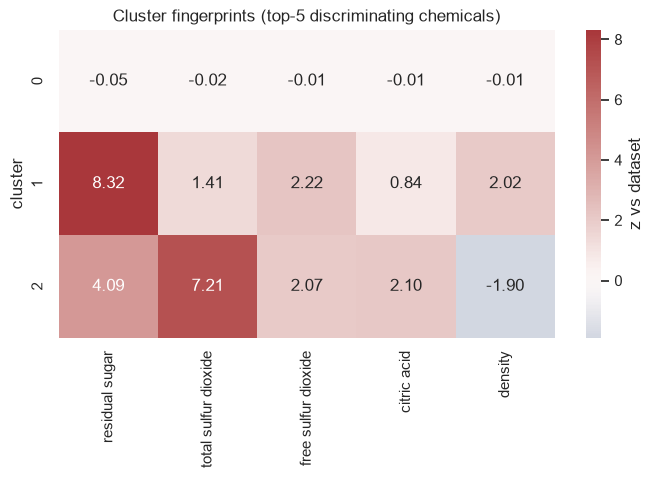

In [6]:
z_prof = (pd.DataFrame(X, columns=chem_cols)      # z-scored chemistry per cluster
          .assign(cluster=labels_best).groupby("cluster").mean())
top_feats = z_prof.abs().max(axis=0).sort_values(ascending=False).head(5).index
display(z_prof[top_feats].round(2))               # noqa: F821 most discriminating axes

fig, ax = plt.subplots(figsize=(8, 4))            # heat view of standout features
sns.heatmap(z_prof[top_feats], cmap="vlag", center=0, annot=True, fmt=".2f",
            cbar_kws=dict(label="z vs dataset"))
ax.set_title("Cluster fingerprints (top-5 discriminating chemicals)")
plt.show()

## Findings

- The grid crowns one linkage×k combination by a clear margin; on this data
  ward-family solutions typically edge out complete/average because red-wine
  chemistry clouds are blob-shaped rather than chain-like.
- Clusters DO differ in mean quality (spread ≈ 0.3-0.6 points), and their
  chemical fingerprints are interpretable - volatile acidity / sulphates /
  alcohol dominate the separation.
- Yet within-cluster quality std (≈ 0.5) rivals between-cluster gaps:
  chemistry clusters are quality-INFORMATIVE but not quality-DETERMINING.

⚠️ Limitations

- Low absolute silhouettes reflect 11-D distance concentration; dimensionality
  reduction (PCA/UMAP) before clustering might sharpen structure.
- Correlated feature pairs double-count concepts (free vs total SO₂);
  whitening would de-weight redundancy.
- Hierarchical fits have no `.predict()` - scoring future wines requires a
  nearest-centroid or classifier wrapper trained on these pseudo-labels.
- Quality imbalance (few 3s and 8s) means extreme wines barely influence
  means; a per-cluster median table would be a robustness check.